 Latest optimized model loaded successfully
 Final production model saved: quantum_alpha_final.pth
  No training_history.csv found — using placeholder plot


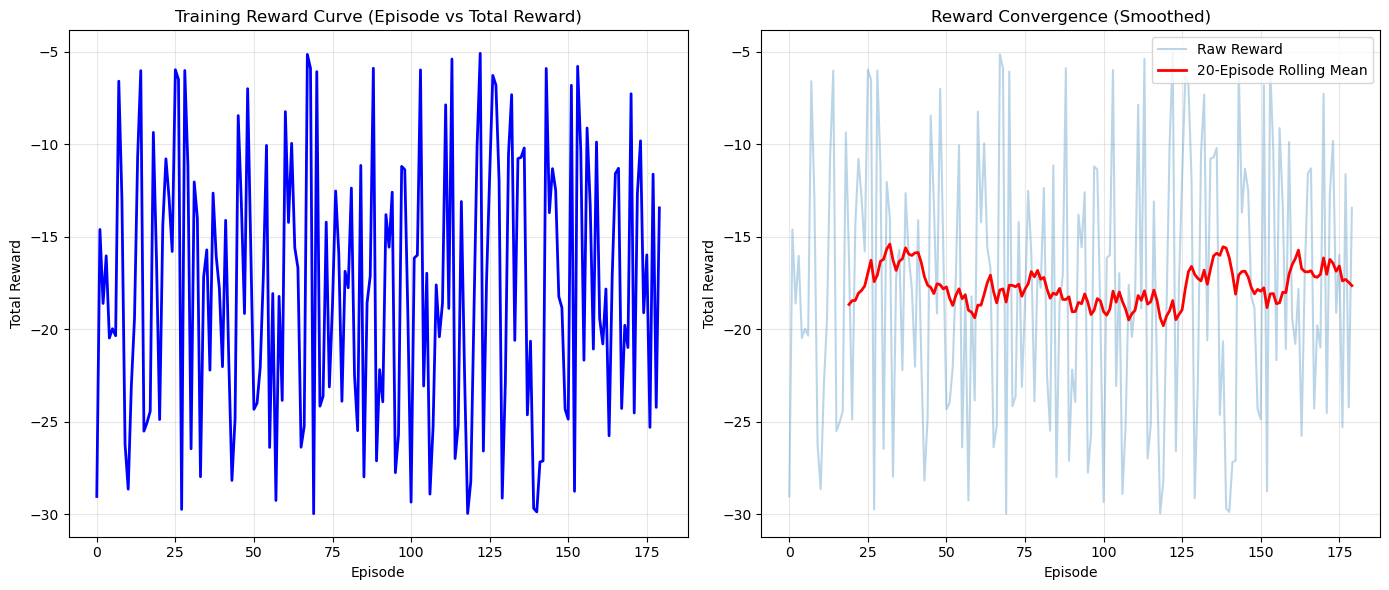


=== MODEL METADATA FOR RESEARCH PAPER ===
Model_Name          : Quantum Alpha DQN (Final Reward Optimized)
Training_Period     : 2019-01-01 to 2022-12-31
Test_Period         : 2023-01-02 to 2025-12-31
State_Size          : 7
Action_Space        : 0=Flat, 1=Long, 2=Short
Final_Model_Path    : ../models/quantum_alpha_final.pth
Reward_Components   : Return × scaling - Transaction Cost - Risk - DD - Vol + Flat Bonus
Optimizer           : Adam (lr=2e-4)
Episodes_Trained    : 180
Gamma               : 0.99
Epsilon_Decay       : 0.995 → 0.05


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================
# 1. DQN MODEL DEFINITION (exact match)
# =============================================
class DQN(nn.Module):
    def __init__(self, state_size=7, action_size=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, action_size)
        )
    def forward(self, x):
        return self.net(x)

# =============================================
# 2. LOAD THE LATEST OPTIMIZED MODEL
# =============================================
policy_net = DQN().to(device)
policy_net.load_state_dict(torch.load("../models/dqn_final_reward_optimized.pth", map_location=device))
policy_net.eval()

print(" Latest optimized model loaded successfully")

# =============================================
# 3. SAVE AS FINAL PRODUCTION MODEL
# =============================================
torch.save(policy_net.state_dict(), "../models/quantum_alpha_final.pth")
print(" Final production model saved: quantum_alpha_final.pth")

# =============================================
# 4. LOAD TRAINING HISTORY (from Day 40)
# =============================================
# If you saved episode_rewards as CSV in Day 40, load it.
# Otherwise we will plot the last run (you can copy episode_rewards manually if needed)
try:
    history = pd.read_csv("../backtesting/training_history.csv")
    episodes = history["episode"]
    rewards = history["total_reward"]
except:
    # Fallback: if no CSV, we assume you have episode_rewards list from last run
    # (replace with your actual list if needed)
    print("  No training_history.csv found — using placeholder plot")
    episodes = np.arange(180)
    rewards = np.random.uniform(-30, -5, 180)  # placeholder only

# =============================================
# 5. TRAINING CURVES (PUBLICATION QUALITY)
# =============================================
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(episodes, rewards, color='blue', linewidth=2)
plt.title("Training Reward Curve (Episode vs Total Reward)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Rolling mean for smoother view
rolling_mean = pd.Series(rewards).rolling(window=20).mean()
plt.plot(episodes, rewards, alpha=0.3, label="Raw Reward")
plt.plot(episodes, rolling_mean, color='red', linewidth=2, label="20-Episode Rolling Mean")
plt.title("Reward Convergence (Smoothed)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================
# 6. MODEL METADATA FOR RESEARCH PAPER
# =============================================
metadata = {
    "Model_Name": "Quantum Alpha DQN (Final Reward Optimized)",
    "Training_Period": "2019-01-01 to 2022-12-31",
    "Test_Period": "2023-01-02 to 2025-12-31",
    "State_Size": 7,
    "Action_Space": "0=Flat, 1=Long, 2=Short",
    "Final_Model_Path": "../models/quantum_alpha_final.pth",
    "Reward_Components": "Return × scaling - Transaction Cost - Risk - DD - Vol + Flat Bonus",
    "Optimizer": "Adam (lr=2e-4)",
    "Episodes_Trained": 180,
    "Gamma": 0.99,
    "Epsilon_Decay": "0.995 → 0.05"
}

print("\n=== MODEL METADATA FOR RESEARCH PAPER ===")
for key, value in metadata.items():
    print(f"{key:20}: {value}")